In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split


In [ ]:

# ---------------
# Task 1: Drop nan values.
# ---------------
df = pd.read_csv('./telescope_data.csv', index_col=0)
df = df.dropna()   

print(df.head())


    fLength    fWidth   fSize   fConc  fConc1     fAsym  fM3Long  fM3Trans  \
0   28.7967   16.0021  2.6449  0.3918  0.1982   27.7004  22.0110   -8.2027   
1   31.6036   11.7235  2.5185  0.5303  0.3773   26.2722  23.8238   -9.9574   
2  162.0520  136.0310  4.0612  0.0374  0.0187  116.7410 -64.8580  -45.2160   
3   23.8172    9.5728  2.3385  0.6147  0.3922   27.2107  -6.4633   -7.1513   
4   75.1362   30.9205  3.1611  0.3168  0.1832   -5.5277  28.5525   21.8393   

    fAlpha     fDist class  
0  40.0920   81.8828     g  
1   6.3609  205.2610     g  
2  76.9600  256.7880     g  
3  10.4490  116.7370     g  
4   4.6480  356.4620     g  


In [8]:

# ---------------
# Task 2: Extract class column.
# ---------------
classes = df['class']
data_matrix = df.drop(columns='class')

print(data_matrix.head())


    fLength    fWidth   fSize   fConc  fConc1     fAsym  fM3Long  fM3Trans  \
0   28.7967   16.0021  2.6449  0.3918  0.1982   27.7004  22.0110   -8.2027   
1   31.6036   11.7235  2.5185  0.5303  0.3773   26.2722  23.8238   -9.9574   
2  162.0520  136.0310  4.0612  0.0374  0.0187  116.7410 -64.8580  -45.2160   
3   23.8172    9.5728  2.3385  0.6147  0.3922   27.2107  -6.4633   -7.1513   
4   75.1362   30.9205  3.1611  0.3168  0.1832   -5.5277  28.5525   21.8393   

    fAlpha     fDist  
0  40.0920   81.8828  
1   6.3609  205.2610  
2  76.9600  256.7880  
3  10.4490  116.7370  
4   4.6480  356.4620  


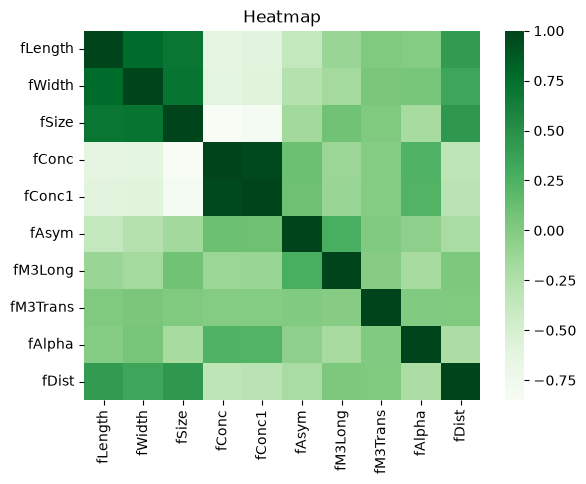

In [9]:

# ---------------
# Task 3: Correlation matrix.
# ---------------
correlation_matrix = data_matrix.corr()
ax = plt.axes()
sns.heatmap(correlation_matrix, cmap='Greens', ax=ax)
ax.set_title('Heatmap')
plt.show()


In [10]:

# ---------------
# Task 4: Eigendecomposition.
# ---------------
eigenvalues, eigenvectors = np.linalg.eig(correlation_matrix)
info_prop = eigenvalues / eigenvalues.sum()
cum_info_prop = np.cumsum(info_prop)

print("Proportion of information per eigenvalue:", info_prop)
print("Cumulative proportions:", cum_info_prop)

# Order eigenvalues/eigenvectors
indices = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[indices]
eigenvectors = eigenvectors[:, indices]

# Standardize
mean = data_matrix.mean(axis=0)
sttd = data_matrix.std(axis=0)
data_matrix_standardized = (data_matrix - mean) / sttd

print(data_matrix_standardized.head())


Proportion of information per eigenvalue: [0.42239909+0.j 0.15751879+0.j 0.00202429+0.j 0.01547534+0.j
 0.02203624+0.j 0.04075386+0.j 0.07420194+0.j 0.06500865+0.j
 0.09940127+0.j 0.10118053+0.j]
Cumulative proportions: [0.42239909+0.j 0.57991788+0.j 0.58194217+0.j 0.59741751+0.j
 0.61945375+0.j 0.66020761+0.j 0.73440955+0.j 0.7994182 +0.j
 0.89881947+0.j 1.        +0.j]
    fLength    fWidth     fSize     fConc    fConc1     fAsym   fM3Long  \
0 -0.577211 -0.336795 -0.381120  0.062758 -0.148919  0.541028  0.224812   
1 -0.510955 -0.570012 -0.648578  0.820362  1.471737  0.516906  0.260357   
2  2.568210  6.205695  2.615714 -1.875834 -1.773194  2.044938 -1.478497   
3 -0.694749 -0.687241 -1.029451  1.282035  1.606566  0.532757 -0.333506   
4  0.516609  0.476371  0.711138 -0.347497 -0.284652 -0.020200  0.353077   

   fM3Trans    fAlpha     fDist  
0 -0.405831  0.476803 -1.497826  
1 -0.490081 -0.815397  0.153121  
2 -2.182972  1.889174  0.842613  
3 -0.355350 -0.658786 -1.031436  
4  1.

c:\Users\apexf\AppData\Local\Programs\Python\Python314\Lib\site-packages\matplotlib\cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\apexf\AppData\Local\Programs\Python\Python314\Lib\site-packages\matplotlib\cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


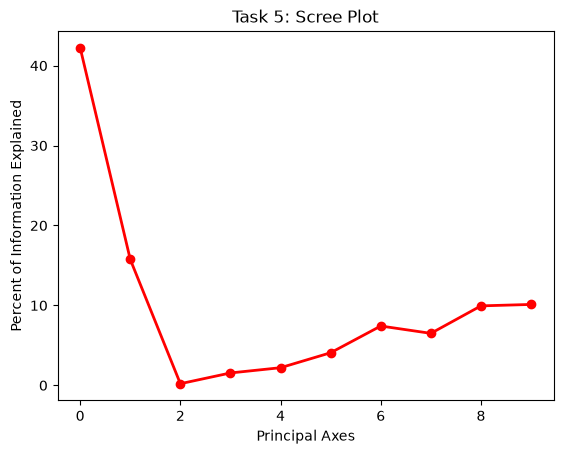

In [ ]:

# Scree Plot
plt.figure()
plt.plot(info_prop * 100, 'ro-', linewidth=2)   
plt.title('Task 5: Scree Plot')
plt.xlabel('Principal Axes')
plt.ylabel('Percent of Information Explained')
plt.show()


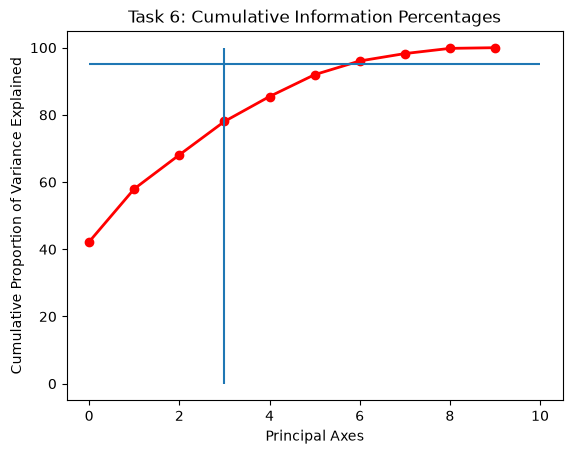

In [ ]:

# ---------------
# Task 6: Cumulative variance percentages.
# ---------------
pca = PCA()
pca.fit(data_matrix_standardized)

cumulative_information_percents = np.cumsum(pca.explained_variance_ratio_ * 100)  

plt.figure()
plt.plot(cumulative_information_percents, 'ro-', linewidth=2)
plt.hlines(y=95, xmin=0, xmax=len(cumulative_information_percents))
plt.vlines(x=3, ymin=0, ymax=100)
plt.title('Task 6: Cumulative Information Percentages')
plt.xlabel('Principal Axes')
plt.ylabel('Cumulative Proportion of Variance Explained')
plt.show()


Eigenvalues: [4.2239909  1.5751879  1.01180532 0.9940127  0.74201939 0.65008647
 0.4075386  0.22036243 0.15475338 0.02024291]
Eigenvectors shape: (10, 10)
Variance ratios: [0.42239909 0.15751879 0.10118053 0.09940127 0.07420194 0.06500865
 0.04075386 0.02203624 0.01547534 0.00202429]


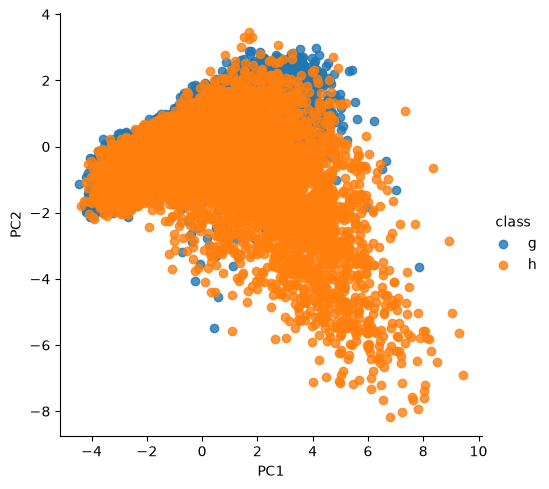

In [ ]:

# Eigenvalues and eigenvectors from PCA
n_samples = data_matrix_standardized.shape[0]
eigenvalues = (pca.singular_values_ ** 2) / (n_samples - 1)
eigenvectors = pca.components_.T
print("Eigenvalues:", eigenvalues)
print("Eigenvectors shape:", eigenvectors.shape)
print("Variance ratios:", pca.explained_variance_ratio_)

# PCA with 2 components
pca2 = PCA(n_components=2)
data_pcomp2 = pca2.fit_transform(data_matrix_standardized)

df_pcomp2 = pd.DataFrame(data_pcomp2, columns=['PC1', 'PC2'])
df_pcomp2['class'] = classes  

sns.lmplot(x='PC1', y='PC2', data=df_pcomp2, hue='class', fit_reg=False)
plt.show()


In [14]:

# SVC with PCA features
X_train, X_test, y_train, y_test = train_test_split(
    data_pcomp2, classes, test_size=0.33, random_state=42
)
svc = SVC()
svc.fit(X_train, y_train)
score_pca = svc.score(X_test, y_test)
print("SVC score with PCA features:", score_pca)


SVC score with PCA features: 0.7417556157400031


In [15]:

# SVC with original first two features
X_train, X_test, y_train, y_test = train_test_split(
    data_matrix_standardized.iloc[:, :2], classes, test_size=0.33, random_state=42
)
svc2 = SVC()
svc2.fit(X_train, y_train)
score_orig = svc2.score(X_test, y_test)
print("SVC score with original features:", score_orig)


SVC score with original features: 0.7291699856619405
